# ChatBS Base Results Analysis

This notebook analyzes the CSV outputs in `analysis/` for the ChatBS base evaluation. It loads the bool/entity/numeric result tables, identifies examples where any configured baseline beats `ours`, and visualizes all available answer win-rate variants: original answer, trace report, and EO report.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 240)

EVALUATION_CONFIG = "config.evaluation.qwen.yaml"  # Change to config.evaluation.chatgpt.yaml for ChatGPT.

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "evaluation_results.py").exists())
DATASET_DIR = REPO_ROOT / "evaluations" / "biomni-base"
CONFIG_PATH = DATASET_DIR / EVALUATION_CONFIG
with CONFIG_PATH.open() as handle:
    EVALUATION_SETTINGS = yaml.safe_load(handle)["evaluation"]
configured_analysis_dir = Path(EVALUATION_SETTINGS["save_dir"])
ANALYSIS_DIR = configured_analysis_dir if configured_analysis_dir.is_absolute() else REPO_ROOT / configured_analysis_dir
JUDGE_ID = EVALUATION_SETTINGS["judge_id"]

ANALYSIS_DIR.resolve()

PosixPath('/home/desild/work/research/LLM-Workflow-Explorer/evaluations/biomni-base/analysis')

## 1. Load Evaluation DataFrames

In [2]:
TASKS = ["bool", "entity", "numeric"]
METHOD_ORDER = [
    "fullcontext",
    "llmbased",
    "vectorsimilarity",
    "hipporag",
    "hypergraphrag",
    "grasp",
    "ours",
]
METHOD_LABELS = {
    "fullcontext": "Full context",
    "llmbased": "LLM-based",
    "vectorsimilarity": "Vector similarity",
    "hipporag": "HippoRAG",
    "hypergraphrag": "HyperGraphRAG",
    "grasp": "GRASP",
    "ours": "Ours",
    "LWE": "Ours",
}
WINRATE_VARIANT_SPECS = [
    ("original", "answer_winrate-original", "Original answer"),
    ("trace", "answer_winrate-trace", "Trace report"),
    ("eo", "answer_winrate-eo", "EO report"),
]
WINRATE_VARIANT_LABELS = {
    key: label for key, _, label in WINRATE_VARIANT_SPECS
}
DEFAULT_WINRATE_VARIANT = EVALUATION_SETTINGS.get("winrate", {}).get("answer_report", "original")


def read_csv_or_empty(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def canonicalize_pairwise_methods(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    if pairwise_df.empty:
        return pairwise_df

    df = pairwise_df.copy()
    original_a = df.get("method_a", pd.Series(index=df.index, dtype=object)).astype(str)
    original_b = df.get("method_b", pd.Series(index=df.index, dtype=object)).astype(str)

    if "method_a_key" in df.columns:
        df["method_a"] = df["method_a_key"].fillna(df["method_a"])
    if "method_b_key" in df.columns:
        df["method_b"] = df["method_b_key"].fillna(df["method_b"])

    if "winning_method" in df.columns:
        winning = df["winning_method"].copy()
        winning = winning.mask(winning.astype(str).eq(original_a), df["method_a"])
        winning = winning.mask(winning.astype(str).eq(original_b), df["method_b"])
        winning = winning.replace({"LWE": "ours"})
        df["winning_method"] = winning

    return df


def load_winrate_variants(analysis_dir: Path) -> tuple[dict[str, pd.DataFrame], dict[str, pd.DataFrame]]:
    pairwise_frames: dict[str, pd.DataFrame] = {}
    summary_frames: dict[str, pd.DataFrame] = {}

    for variant, dirname, _label in WINRATE_VARIANT_SPECS:
        variant_dir = analysis_dir / dirname
        pairwise_path = variant_dir / "pairwise_answer_winrate.csv"
        summary_path = variant_dir / "answer_winrate_summary.csv"
        pairwise_df = canonicalize_pairwise_methods(read_csv_or_empty(pairwise_path))
        summary_df = read_csv_or_empty(summary_path)
        if not pairwise_df.empty:
            pairwise_df.insert(0, "winrate_variant", variant)
        if not summary_df.empty:
            summary_df = summary_df.copy()
            summary_df["method"] = summary_df["method"].replace({"LWE": "ours"})
            summary_df.insert(0, "winrate_variant", variant)
        pairwise_frames[variant] = pairwise_df
        summary_frames[variant] = summary_df

    # Backward-compatible fallback for older runs that wrote analysis/answer_winrate.
    if not any(not df.empty for df in pairwise_frames.values()):
        legacy_dir = analysis_dir / "answer_winrate"
        legacy_pairwise = canonicalize_pairwise_methods(read_csv_or_empty(legacy_dir / "pairwise_answer_winrate.csv"))
        legacy_summary = read_csv_or_empty(legacy_dir / "answer_winrate_summary.csv")
        if not legacy_pairwise.empty:
            legacy_pairwise.insert(0, "winrate_variant", DEFAULT_WINRATE_VARIANT)
            pairwise_frames[DEFAULT_WINRATE_VARIANT] = legacy_pairwise
        if not legacy_summary.empty:
            legacy_summary = legacy_summary.copy()
            legacy_summary["method"] = legacy_summary["method"].replace({"LWE": "ours"})
            legacy_summary.insert(0, "winrate_variant", DEFAULT_WINRATE_VARIANT)
            summary_frames[DEFAULT_WINRATE_VARIANT] = legacy_summary

    return pairwise_frames, summary_frames


results = {
    task: pd.read_csv(ANALYSIS_DIR / task / "results.csv")
    for task in TASKS
}
summaries = {
    task: pd.read_csv(ANALYSIS_DIR / task / "results_summary.csv")
    for task in TASKS
}
pairwise_by_variant, winrate_summary_by_variant = load_winrate_variants(ANALYSIS_DIR)
pairwise = pairwise_by_variant.get(DEFAULT_WINRATE_VARIANT, pd.DataFrame())
winrate_summary = winrate_summary_by_variant.get(DEFAULT_WINRATE_VARIANT, pd.DataFrame())
all_pairwise = pd.concat(
    [df for df in pairwise_by_variant.values() if not df.empty],
    ignore_index=True,
) if any(not df.empty for df in pairwise_by_variant.values()) else pd.DataFrame()
all_winrate_summary = pd.concat(
    [df for df in winrate_summary_by_variant.values() if not df.empty],
    ignore_index=True,
) if any(not df.empty for df in winrate_summary_by_variant.values()) else pd.DataFrame()

observed_methods = set()
for df in results.values():
    observed_methods.update(df["run"].dropna().astype(str).unique())
for variant_pairwise in pairwise_by_variant.values():
    if not variant_pairwise.empty:
        observed_methods.update(variant_pairwise["method_a"].dropna().astype(str).unique())
        observed_methods.update(variant_pairwise["method_b"].dropna().astype(str).unique())

METHODS = [method for method in METHOD_ORDER if method in observed_methods]
BASELINE_METHODS = [method for method in METHODS if method != "ours"]

for task, df in results.items():
    print(f"{task:>7}: {df.shape[0]} rows x {df.shape[1]} columns | runs={sorted(df['run'].dropna().unique())}")
for variant, df in pairwise_by_variant.items():
    label = WINRATE_VARIANT_LABELS.get(variant, variant)
    print(f"{variant:>8}: {df.shape[0]} pairwise rows x {df.shape[1]} columns | {label}")
print(f"baselines: {BASELINE_METHODS}")


   bool: 273 rows x 34 columns | runs=['fullcontext', 'grasp', 'hipporag', 'hypergraphrag', 'llmbased', 'ours', 'vectorsimilarity']
 entity: 322 rows x 43 columns | runs=['fullcontext', 'grasp', 'hipporag', 'hypergraphrag', 'llmbased', 'ours', 'vectorsimilarity']
numeric: 147 rows x 34 columns | runs=['fullcontext', 'grasp', 'hipporag', 'hypergraphrag', 'llmbased', 'ours', 'vectorsimilarity']
original: 636 pairwise rows x 16 columns | Original answer
   trace: 0 pairwise rows x 0 columns | Trace report
      eo: 0 pairwise rows x 0 columns | EO report
baselines: ['fullcontext', 'llmbased', 'vectorsimilarity', 'hipporag', 'hypergraphrag', 'grasp']


In [3]:
summary_tables = []
for task, df in summaries.items():
    tmp = df.copy()
    tmp.insert(0, "task", task)
    summary_tables.append(tmp)

combined_summary = pd.concat(summary_tables, ignore_index=True)
combined_summary

,task,run,evaluated_examples,matched_ground_truth,avg_prediction_time_taken,answer_token_precision_mean,answer_token_precision_std,answer_token_recall_mean,answer_token_recall_std,answer_token_f1_mean,answer_token_f1_std,gt_entity_total_mean,gt_entity_total_std,gt_entity_covered_mean,gt_entity_covered_std,gt_entity_coverage_mean,gt_entity_coverage_std,bertscore_precision_mean,bertscore_precision_std,bertscore_recall_mean,bertscore_recall_std,bertscore_f1_mean,bertscore_f1_std,llm_completeness_mean,llm_completeness_std,llm_faithfulness_mean,llm_faithfulness_std,llm_relevance_mean,llm_relevance_std,llm_understanderbility_mean,llm_understanderbility_std,nli_entailment_max_mean,nli_entailment_max_std,bool_accuracy_mean,bool_accuracy_std,entity_gt_total_mean,entity_gt_total_std,entity_retrieved_final_total_mean,entity_retrieved_final_total_std,entity_retrieved_total_total_mean,entity_retrieved_total_total_std,entity_recall_final_mean,entity_recall_final_std,entity_precision_final_mean,entity_precision_final_std,entity_f1_final_mean,entity_f1_final_std,entity_recall_total_mean,entity_recall_total_std,entity_precision_total_mean,entity_precision_total_std,entity_f1_total_mean,entity_f1_total_std,numeric_ground_truth_count_mean,numeric_ground_truth_count_std,numeric_predicted_count_mean,numeric_predicted_count_std,numeric_accuracy_mean,numeric_accuracy_std
0,bool,fullcontext,39,39,4.438063,0.561577,0.119374,0.501599,0.219032,0.507475,0.155126,1.769231,1.111224,0.333333,0.477567,0.117521,0.179055,0.825013,0.018980,0.856685,0.037158,0.840080,0.021050,0.076923,0.244370,0.071795,0.253345,0.687179,0.389453,0.830769,0.052082,0.597792,0.266248,0.333333,0.477567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bool,grasp,39,39,18.201104,0.144914,0.240539,0.104874,0.173380,0.105816,0.162966,1.769231,1.111224,0.128205,0.338688,0.051282,0.138675,0.829874,0.046404,0.781417,0.054768,0.802916,0.030243,0.517949,0.467283,0.543590,0.487094,0.903846,0.267637,0.830769,0.119547,0.345380,0.373760,0.205128,0.409074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bool,hipporag,39,39,3.959946,0.017094,0.106752,0.004049,0.025283,0.006547,0.040884,1.769231,1.111224,0.538462,0.505035,0.378205,0.428706,0.708460,0.009356,0.761135,0.011452,0.733791,0.007681,0.430769,0.497443,0.435897,0.502356,0.871795,0.338688,0.971795,0.068628,0.309484,0.326041,0.564103,0.502356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bool,hypergraphrag,39,39,15.605655,0.370893,0.109220,0.636838,0.265981,0.451860,0.153380,1.769231,1.111224,0.538462,0.789609,0.200855,0.324284,0.852384,0.028896,0.862619,0.046262,0.857153,0.035073,0.235897,0.376610,0.248718,0.409667,0.867949,0.289620,0.794872,0.082554,0.397891,0.320603,0.461538,0.505035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bool,llmbased,39,39,0.901822,0.189572,0.091635,0.111540,0.029334,0.136168,0.038728,1.769231,1.111224,0.000000,0.000000,0.000000,0.000000,0.765635,0.015120,0.784050,0.013114,0.774664,0.012007,0.041026,0.081815,0.020513,0.040907,0.100000,0.168585,0.720513,0.117383,0.234151,0.288883,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,bool,ours,39,39,236.440208,0.259225,0.101103,0.812431,0.115826,0.380787,0.109483,1.769231,1.111224,0.384615,0.492864,0.190171,0.296143,0.791643,0.022621,0.872135,0.018670,0.829821,0.018570,0.741026,0.416576,0.755128,0.420337,0.990513,0.022589,0.787179,0.033869,0.455366,0.266390,0.769231,0.426833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,bool,vectorsimilarity,39,39,2.839674,0.353571,0.297826,0.267631,0.249763,0.295475,0.256393,1.769231,1.111224,0.256410,0.442359,0.096154,0.201001,0.785002,0.017683,0.801709,0.028873,0.793165,0.021823,0.102564,0.226515,0.107692,0.285053,0.723

## 2. Examples Where Baselines Are Right But Ours Is Wrong

For bool and numeric tasks, correctness is defined by exact `*_accuracy == 1`. An example is flagged when at least one available baseline is correct and `ours` is incorrect. For entity tasks, this notebook uses the LLM judge pairwise scores: an example is flagged when at least one available baseline has a higher average judge score than `ours` for the same `ground_truth_id`.


In [4]:
def metric_pivot(task: str, metric: str) -> pd.DataFrame:
    df = results[task].copy()
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    return df.pivot_table(
        index="ground_truth_id",
        columns="run",
        values=metric,
        aggfunc="mean",
    )


def answer_pivot(task: str) -> pd.DataFrame:
    return results[task].pivot_table(
        index="ground_truth_id",
        columns="run",
        values="pred_answer",
        aggfunc="first",
    ).add_prefix("answer_")


def question_frame(task: str) -> pd.DataFrame:
    return (
        results[task]
        .drop_duplicates("ground_truth_id")[["ground_truth_id", "question", "ground_truth_answer", "ground_truth_qtype"]]
        .set_index("ground_truth_id")
    )


def sort_by_ground_truth_id(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "ground_truth_id" not in df.columns:
        return df
    return df.sort_values(
        "ground_truth_id",
        key=lambda s: pd.to_numeric(s.str.extract(r"(\d+)", expand=False), errors="coerce"),
    )


def ordered_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [column for column in columns if column in df.columns]


def empty_hard_case_frame(extra_columns: list[str] | None = None) -> pd.DataFrame:
    columns = ["ground_truth_id", "question", "ground_truth_answer"]
    if extra_columns:
        columns.extend(extra_columns)
    return pd.DataFrame(columns=columns)


def baseline_right_ours_wrong(task: str, metric: str) -> pd.DataFrame:
    scores = metric_pivot(task, metric)
    if "ours" not in scores.columns:
        raise ValueError(f"Missing `ours` run for {task}")

    baseline_cols = [method for method in BASELINE_METHODS if method in scores.columns]
    if not baseline_cols:
        raise ValueError(f"Missing baseline runs for {task}")

    mask = scores[baseline_cols].eq(1.0).any(axis=1) & scores["ours"].eq(0.0)
    if not mask.any():
        return empty_hard_case_frame(["correct_baselines"])

    out = (
        question_frame(task)
        .join(scores.add_suffix(f"_{metric}"))
        .join(answer_pivot(task))
        .loc[mask]
        .reset_index()
    )
    out["correct_baselines"] = [
        ", ".join(method for method in baseline_cols if row.get(method) == 1.0)
        for row in scores.loc[mask, baseline_cols].to_dict("records")
    ]
    return sort_by_ground_truth_id(out)


def example_display_columns(df: pd.DataFrame, metric: str | None = None, score_suffix: str | None = None) -> list[str]:
    base = ["ground_truth_id", "question", "ground_truth_answer"]
    if "correct_baselines" in df.columns:
        base.append("correct_baselines")
    if "higher_scoring_baselines" in df.columns:
        base.append("higher_scoring_baselines")

    if metric:
        base.extend(f"{method}_{metric}" for method in [*BASELINE_METHODS, "ours"])
    if score_suffix:
        base.extend(f"{method}_{score_suffix}" for method in [*BASELINE_METHODS, "ours"])
    base.extend(f"answer_{method}" for method in [*BASELINE_METHODS, "ours"])
    return ordered_columns(df, base)


bool_baselines_right_ours_wrong = baseline_right_ours_wrong("bool", "bool_accuracy")
numeric_baselines_right_ours_wrong = baseline_right_ours_wrong("numeric", "numeric_accuracy")

print("Bool examples:", len(bool_baselines_right_ours_wrong))
print("Numeric examples:", len(numeric_baselines_right_ours_wrong))


Bool examples: 9
Numeric examples: 3


In [5]:
bool_baselines_right_ours_wrong[example_display_columns(
    bool_baselines_right_ours_wrong,
    metric="bool_accuracy",
)]


,ground_truth_id,question,ground_truth_answer,correct_baselines,fullcontext_bool_accuracy,llmbased_bool_accuracy,vectorsimilarity_bool_accuracy,hipporag_bool_accuracy,hypergraphrag_bool_accuracy,grasp_bool_accuracy,ours_bool_accuracy,answer_fullcontext,answer_llmbased,answer_vectorsimilarity,answer_hipporag,answer_hypergraphrag,answer_grasp,answer_ours
0,gt_27,"\nIs the function with a description as ""Step 10 - Biomni critic review 1"" made by using Large Language Model output?\n",\n The Step 10 - Biomni critic review 1 function is not made by a Generative Task.\n\n fnlbl | Generative Task used to generate function\nStep 10 - Biomni critic review 1 | None\n,"fullcontext, hipporag, hypergraphrag",1.0,0.0,0.0,1.0,1.0,0.0,0.0,"No, there is no function with that description in the provided graph.","The closest grounded workflow step is SPARQL Query Builder (sparql query 1 1 10); used extracts, row 1; generated extracts, kg info, row 1.",Insufficient information.,No.,No – there is no record in the provided data indicating that a function described as “Step 10 – Biomni critic review 1” was produced by a Large Language Model output.,NaN,"Yes. The function identified by the URI **http://testwebsite/testProgram#critic_review_1** is the program that implements “Step 10 – Biomni critic review 1”. Its provone:label and dc:description confirm this role: * `rdfs:label = ""Step ..."
1,gt_28,"\nIs the function with a description as ""Step 4 - Biomni LLM generation iteration 1"" made by using Large Language Model output?\n",\n The Step 4 - Biomni LLM generation iteration 1 function is not made by a Generative Task.\n\n fnlbl | Generative Task used to generate function\nStep 4 - Biomni LLM generation iteration 1 | None\n,"fullcontext, hipporag, hypergraphrag",1.0,0.0,0.0,1.0,1.0,0.0,0.0,"No, the graph does not contain a function described as “Step 4 – Biomni LLM generation iteration 1.”",The Information Extractor execution used the gpt-4o model to handle the prompt with inputs generated answer.,Insufficient information,No.,"**Answer** No, there is no record in the provided data indicating a function titled “Step 4 – Biomni LLM generation iteration 1” that was produced via a large‑language‑model (LLM) output. All listed functions and outputs reference gener...","Yes, the function is generated by a Large Language Model.",Yes. The program *Biomni:generate_agent_response_1* (label “Step 4 – Biomni LLM generation iteration 1”) was instantiated by a Large‑Language‑Model output. In the provenance graph: 1. **Type of artifact** – `http://testwebsite/testProgr...
2,gt_29,"\nIs the function with a description as ""Step 5 - Biomni LLM generation iteration 2"" made by using Large Language Model output?\n",\n The Step 5 - Biomni LLM generation iteration 2 function is not made by a Generative Task.\n\n fnlbl | Generative Task used to generate function\nStep 5 - Biomni LLM generation iteration 2 | None\n,"fullcontext, hipporag, hypergraphrag",1.0,0.0,0.0,1.0,1.0,0.0,0.0,"No, the graph does not contain a function described as ""Step 5 – Biomni LLM generation iteration 2"".",The Information Extractor execution used the gpt-4o model to handle the prompt with inputs generated answer.,"The retrieved object descriptions do not contain a function with the description ""Step 5 - Biomni LLM generation iteration 2"", so it is impossible to confirm whether such a function was made using Large Language Model output based solel...",No.,"No, there is no record in the provided data of a function whose description is “Step 5 – Biomni LLM generation iteration 2.” All listed functions have descriptions such as *Generates the post‑processing Function using Large language mod...",NaN,Yes. The entity that represents the function “Step 5 – Biomni LLM generation iteration 2” is typed as a **workflow:Large_Language_Model_Output** (see the RDF triple `http://testwebsite/testProgram#LLM_Output-id_20260505001009_972 rdf:ty...
3,gt_30,"\nIs the function with a description as ""Step 6 -

In [6]:
numeric_baselines_right_ours_wrong[example_display_columns(
    numeric_baselines_right_ours_wrong,
    metric="numeric_accuracy",
)]


,ground_truth_id,question,ground_truth_answer,correct_baselines,fullcontext_numeric_accuracy,llmbased_numeric_accuracy,vectorsimilarity_numeric_accuracy,hipporag_numeric_accuracy,hypergraphrag_numeric_accuracy,grasp_numeric_accuracy,ours_numeric_accuracy,answer_fullcontext,answer_llmbased,answer_vectorsimilarity,answer_hipporag,answer_hypergraphrag,answer_grasp,answer_ours
0,gt_91,"\nwhat is the number of output for the ""Step 4 - next_step output port for generation iteration 1"" in the execution ""http://testwebsite/testProgram#id_20260505001006_475"" ?\n","\n The number of output for the ""Step 4 - next_step output port for generation iteration 1"" in the execution ""http://testwebsite/testProgram#id_20260505001006_475"" is 1\n\n Output Data\nhttp://testwebsite/testProgram#Data-id_20260...",hipporag,0.0,1.0,0.0,0.0,0.0,0.0,0.0,I cannot determine that value from the supplied provenance data.,"The row 1 was produced by the Query Result Post-Processor execution and then used by Query Result Post-Processor to produce ChatBS-NexGen:id_20260420105727_995, post processed output.",Insufficient information,Insufficient information to answer.,"I’m sorry, but the provided provenance data does not contain any information about a “Step 4 – next_step output port for generation iteration 1” in the execution identified by `http://testwebsite/testProgram#id_20260505001006_475`. No e...",NaN,The execution **http://testwebsite/testProgram#id_20260505001006_475** (Step 4 – generate_agent_response iteration 1) produced exactly one output artifact on its “next_step” output port. This is evidenced by the presence of a single `pr...
1,gt_97,"\nwhat is the number of output for the ""Step 5 - response output port for generation iteration 2"" in the execution ""http://testwebsite/testProgram#id_20260505001009_972"" ?\n","\n The number of output for the ""Step 5 - response output port for generation iteration 2"" in the execution ""http://testwebsite/testProgram#id_20260505001009_972"" is 1\n\n Output Data\nhttp://testwebsite/testProgram#Data-id_202605...",llmbased,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"The graph does not contain any information about a ""Step 5 – response output port for generation iteration 2"" associated with the execution <http://testwebsite/testProgram#id_20260505001009_972>.",The gpt-4o model.,Insufficient information,1,"I’m sorry, but the provided provenance records do not contain any information about a “Step 5 – response output port for generation iteration 2” in the execution identified by `http://testwebsite/testProgram#id_20260505001009_972`. Cons...",NaN,The execution `http://testwebsite/testProgram#id_20260505001009_972` contains two output ports produced by the Generation activity of Step 5. - **Step 5 – next agent step output** (`Biomni:generate_agent_response_2-next_step`) - **Step ...
2,gt_101,"\nwhat is the number of output for the ""Step 6 - response output port for generation iteration 3"" in the execution ""http://testwebsite/testProgram#id_20260505001011_890"" ?\n","\n The number of output for the ""Step 6 - response output port for generation iteration 3"" in the execution ""http://testwebsite/testProgram#id_20260505001011_890"" is 1\n\n Output Data\nhttp://testwebsite/testProgram#Data-id_202605...",hipporag,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"The graph does not contain the execution with ID `http://testwebsite/testProgram#id_20260505001011_890`, so I cannot provide a number of outputs for Step 6.",The gpt-4o model.,Insufficient information,1,"I’m sorry, but I don’t have any information about a “Step 6 – response output port for generation iteration 3” in the execution `http://testwebsite/testProgram#id_20260505001011_890`. The provided provenance data does not contain an ent...",NaN,"The “Step 6 – response output port” in the execution `http://testwebsite/testProgram#id_20260505001011_890` produces **one** output artifact (the LLM response). This is evidenced by the single qualified generation record for this step, ..."


In [7]:
if pairwise.empty:
    entity_baselines_higher_ours_lower = empty_hard_case_frame(["higher_scoring_baselines"])
else:
    entity_pairwise = pairwise[pairwise["ground_truth_qtype"].str.contains("entity", na=False)].copy()
    score_rows = []
    for _, row in entity_pairwise.iterrows():
        score_rows.append({
            "ground_truth_id": row["ground_truth_id"],
            "method": row["method_a"],
            "llm_score": row["method_a_score"],
        })
        score_rows.append({
            "ground_truth_id": row["ground_truth_id"],
            "method": row["method_b"],
            "llm_score": row["method_b_score"],
        })

    entity_scores_long = pd.DataFrame(score_rows)
    if entity_scores_long.empty:
        entity_baselines_higher_ours_lower = empty_hard_case_frame(["higher_scoring_baselines"])
    else:
        entity_scores_long["llm_score"] = pd.to_numeric(entity_scores_long["llm_score"], errors="coerce")
        entity_scores = entity_scores_long.pivot_table(
            index="ground_truth_id",
            columns="method",
            values="llm_score",
            aggfunc="mean",
        )

        if "ours" not in entity_scores.columns:
            entity_baselines_higher_ours_lower = empty_hard_case_frame(["higher_scoring_baselines"])
        else:
            entity_baseline_cols = [method for method in BASELINE_METHODS if method in entity_scores.columns]
            entity_mask = entity_scores[entity_baseline_cols].gt(entity_scores["ours"], axis=0).any(axis=1)

            if not entity_mask.any():
                entity_baselines_higher_ours_lower = empty_hard_case_frame(["higher_scoring_baselines"])
            else:
                entity_baselines_higher_ours_lower = (
                    question_frame("entity")
                    .join(entity_scores.add_suffix("_avg_llm_score"))
                    .join(answer_pivot("entity"))
                    .loc[entity_mask]
                    .reset_index()
                )
                entity_baselines_higher_ours_lower["higher_scoring_baselines"] = [
                    ", ".join(
                        method
                        for method in entity_baseline_cols
                        if row.get(method, float("nan")) > row.get("ours", float("nan"))
                    )
                    for row in entity_scores.loc[entity_mask, [*entity_baseline_cols, "ours"]].to_dict("records")
                ]
                entity_baselines_higher_ours_lower = sort_by_ground_truth_id(entity_baselines_higher_ours_lower)

print("Entity examples:", len(entity_baselines_higher_ours_lower))
entity_baselines_higher_ours_lower[example_display_columns(
    entity_baselines_higher_ours_lower,
    score_suffix="avg_llm_score",
)]


Entity examples: 7


,ground_truth_id,question,ground_truth_answer,higher_scoring_baselines,fullcontext_avg_llm_score,llmbased_avg_llm_score,vectorsimilarity_avg_llm_score,hipporag_avg_llm_score,hypergraphrag_avg_llm_score,grasp_avg_llm_score,ours_avg_llm_score,answer_fullcontext,answer_llmbased,answer_vectorsimilarity,answer_hipporag,answer_hypergraphrag,answer_grasp,answer_ours
0,gt_6,"\nwhat are the input parameters of the function used in ""Step 8 - Biomni LLM generation iteration 4"" step in the pipeline?\n",\n The input parameters to Step 8 - Biomni LLM generation iteration 4 function.\n\n Funtion name | Function returns\nStep 8 - Biomni LLM generation iteration 4 | Step 8 - agent state message input\nStep 8 - Biomni LLM generation i...,hypergraphrag,0.0,0.0,0.0,0.0,1.0,0.0,0.833333,"The function used in Step 8 of the Biomni LLM generation pipeline (the Query Result Post‑Processor) takes a single input – the `kg_knowledge` port, which carries the combined knowledge‑graph results produced by the batch SPARQL query ex...","The LLM Chat execution (llm chat 1 1) ran with inputs user prompt, system prompt and produced system prompt, generated answer.",The function used in Step 8 requires two input parameters: 1. An **input formatting instruction** (ChatBS-NexGen:LLM-query_result_post_processor-Input-formatting_instruction). 2. An **input processing instruction** (ChatBS-NexGen:LLM-qu...,Unable to provide the input parameters because the necessary context is missing.,"**Input Parameters for the Function in “Step 8 – Biomni LLM Generation Iteration 4”** | Parameter | Description | |-----------|-------------| | **system_prompt** | The base system instruction that tells the model its role (e.g., *“You a...",NaN,"The “Step 8 – Biomni LLM generation iteration 4” step is driven by the **generate_agent_response_4** function, which in turn calls a large‑language model (LLM). From the provenance graph we can identify the literal values that were fed ..."
1,gt_18,\nwhat are the executions of the Step 4 - Biomni LLM generation iteration 1 step in the pipeline?\n,\n The executions of the Step 4 - Biomni LLM generation iteration 1 function are.\n\n Executions\nhttp://testwebsite/testProgram#id_20260505001006_475\n,hypergraphrag,0.0,0.0,0.0,0.0,1.0,0.0,0.833333,"The provenance knowledge graph does not contain any entities, executions, or events that are labeled as ""Step 4 – Biomni LLM generation iteration 1"" or that can be mapped to such a step in the described pipeline.",The gpt-4o model.,The retrieved objects do not contain any information about Step 4 – Biomni LLM generation iteration 1 in the pipeline.,Insufficient information to determine the executions of Step 4 – Biomni LLM generation iteration 1.,"**Step 4 – Biomni LLM Generation Iteration 1 (Pipeline Execution Overview)** In the first iteration of the Biomni LLM generation pipeline, Step 4 is responsible for post‑processing the raw text produced by the language model before it i...",NaN,"**Execution for Step 4 – Biomni LLM generation iteration 1** | Property | Value | |----------|-------| | **URI / Identifier** | `Biomni:id_20260505001006_475` (`id_20260505001006_475`, `generate_agent_response_1`) | | **Label** | “Step ..."
2,gt_20,\nwhat are the executions of the Step 6 - Biomni LLM generation iteration 3 step in the pipeline?\n,\n The executions of the Step 6 - Biomni LLM generation iteration 3 function are.\n\n Executions\nhttp://testwebsite/testProgram#id_20260505001011_890\n,fullcontext,0.0,0.0,0.0,0.0,1.0,0.0,0.833333,"The provenance graph does not contain any execution that is explicitly identified as ""Step 6 – Biomni LLM generation iteration 3"". Therefore, no such execution can be reported.",The gpt-4o model.,The provided object descriptions do not contain any information about Step 6 – Biomni LLM generation iteration 3 or its executions.,None.,"**Step 6 – Biomni LLM Generation Iteration 3 (Query‑Result Post‑Processor)** In the third iteration of the Biomni pipeline, Step 6 is responsible f

### Compact `gt_id` Lists

In [8]:
hard_case_ids = {
    "bool": bool_baselines_right_ours_wrong.get("ground_truth_id", pd.Series(dtype=str)).tolist(),
    "entity": entity_baselines_higher_ours_lower.get("ground_truth_id", pd.Series(dtype=str)).tolist(),
    "numeric": numeric_baselines_right_ours_wrong.get("ground_truth_id", pd.Series(dtype=str)).tolist(),
}
hard_case_ids


{'bool': ['gt_27',
  'gt_28',
  'gt_29',
  'gt_30',
  'gt_31',
  'gt_37',
  'gt_41',
  'gt_62',
  'gt_63'],
 'entity': ['gt_6', 'gt_18', 'gt_20', 'gt_25', 'gt_44', 'gt_46', 'gt_47'],
 'numeric': ['gt_91', 'gt_97', 'gt_101']}

## 3. Pairwise Win Rate: Ours vs Baselines

This section graphs every available answer win-rate variant under `analysis/answer_winrate-*`: original answer, trace report, and EO report.


In [9]:
def pairwise_ours_summary(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    if pairwise_df.empty:
        return pd.DataFrame(columns=[
            "opponent", "comparisons", "ours_wins", "opponent_wins", "ties", "ours_winrate", "opponent_winrate"
        ])

    rows = []
    ours_rows = pairwise_df[(pairwise_df["method_a"].eq("ours")) | (pairwise_df["method_b"].eq("ours"))].copy()
    if ours_rows.empty:
        return pd.DataFrame(columns=[
            "opponent", "comparisons", "ours_wins", "opponent_wins", "ties", "ours_winrate", "opponent_winrate"
        ])

    opponents = ours_rows.apply(
        lambda r: r["method_b"] if r["method_a"] == "ours" else r["method_a"],
        axis=1,
    )
    for opponent, grp in ours_rows.groupby(opponents):
        total = len(grp)
        ours_wins = grp["winning_method"].eq("ours").sum()
        opponent_wins = grp["winning_method"].eq(opponent).sum()
        ties = total - ours_wins - opponent_wins
        rows.append({
            "opponent": opponent,
            "comparisons": total,
            "ours_wins": int(ours_wins),
            "opponent_wins": int(opponent_wins),
            "ties": int(ties),
            "ours_winrate": (ours_wins + 0.5 * ties) / total if total else float("nan"),
            "opponent_winrate": (opponent_wins + 0.5 * ties) / total if total else float("nan"),
        })

    order = [method for method in BASELINE_METHODS if method in {row["opponent"] for row in rows}]
    return pd.DataFrame(rows).assign(
        opponent=lambda d: pd.Categorical(d["opponent"], categories=order, ordered=True)
    ).sort_values("opponent").reset_index(drop=True)


def pairwise_ours_summary_by_variant(pairwise_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    frames = []
    for variant, variant_pairwise in pairwise_frames.items():
        summary = pairwise_ours_summary(variant_pairwise)
        if summary.empty:
            continue
        summary.insert(0, "winrate_variant", variant)
        summary.insert(1, "winrate_variant_label", WINRATE_VARIANT_LABELS.get(variant, variant))
        frames.append(summary)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


ours_vs_baselines_by_variant = pairwise_ours_summary_by_variant(pairwise_by_variant)
ours_vs_baselines = pairwise_ours_summary(pairwise)
ours_vs_baselines_by_variant


,winrate_variant,winrate_variant_label,opponent,comparisons,ours_wins,opponent_wins,ties,ours_winrate,opponent_winrate
0,original,Original answer,fullcontext,106,95,11,0,0.896226,0.103774
1,original,Original answer,llmbased,106,104,2,0,0.981132,0.018868
2,original,Original answer,vectorsimilarity,106,101,5,0,0.952830,0.047170
3,original,Original answer,hipporag,106,96,10,0,0.905660,0.094340
4,original,Original answer,hypergraphrag,106,90,16,0,0.849057,0.150943
5,original,Original answer,grasp,106,103,3,0,0.971698,0.028302


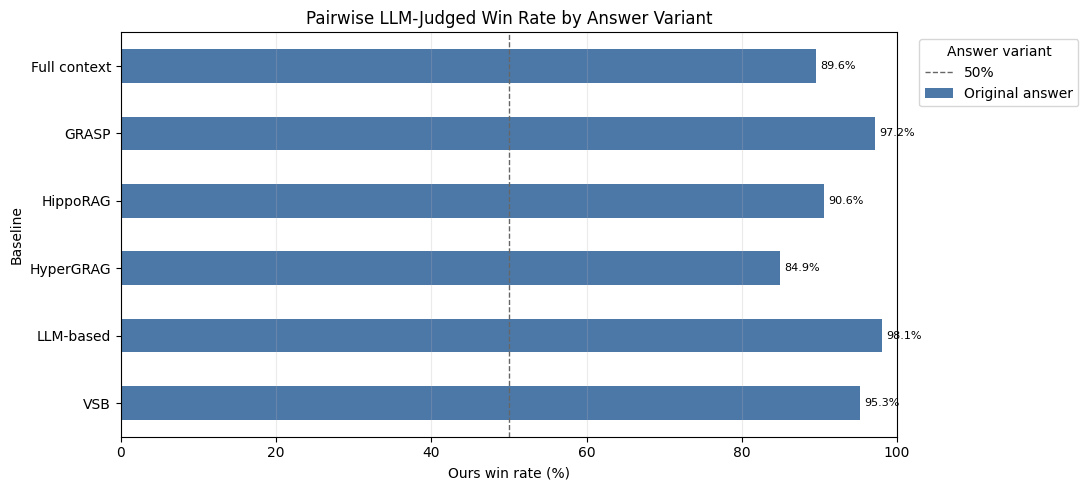

In [10]:
WINRATE_GRAPH_BASELINE_ORDER = [method for method in METHOD_ORDER if method != "ours"]
WINRATE_GRAPH_LABELS = {
    **METHOD_LABELS,
    "vectorsimilarity": "VSB",
    "grasp": "GRASP",
    "hipporag": "HippoRAG",
    "hypergraphrag": "HyperGRAG",
}
VARIANT_COLORS = {
    "original": "#4C78A8",
    "trace": "#F58518",
    "eo": "#54A24B",
}

plot_df = ours_vs_baselines_by_variant.copy()
plot_df = plot_df[plot_df["opponent"].astype(str).isin(WINRATE_GRAPH_BASELINE_ORDER)].copy()
plot_df["opponent"] = pd.Categorical(
    plot_df["opponent"].astype(str),
    categories=WINRATE_GRAPH_BASELINE_ORDER,
    ordered=True,
)
plot_df["winrate_variant"] = pd.Categorical(
    plot_df["winrate_variant"],
    categories=[variant for variant, _dirname, _label in WINRATE_VARIANT_SPECS],
    ordered=True,
)
plot_df = plot_df.sort_values(["opponent", "winrate_variant"]).reset_index(drop=True)
plot_df["opponent_label"] = plot_df["opponent"].astype(str).map(lambda x: WINRATE_GRAPH_LABELS.get(x, x))
plot_df["ours_winrate_pct"] = plot_df["ours_winrate"] * 100

pivot_plot = plot_df.pivot_table(
    index="opponent_label",
    columns="winrate_variant_label",
    values="ours_winrate_pct",
    aggfunc="mean",
    observed=False,
)
variant_column_order = [
    WINRATE_VARIANT_LABELS[variant]
    for variant, _dirname, _label in WINRATE_VARIANT_SPECS
    if WINRATE_VARIANT_LABELS[variant] in pivot_plot.columns
]
pivot_plot = pivot_plot[variant_column_order]

ax = pivot_plot.plot(
    kind="barh",
    figsize=(11, max(5, 0.55 * max(len(pivot_plot), 1))),
    color=[VARIANT_COLORS.get(variant, None) for variant in ["original", "trace", "eo"][:len(variant_column_order)]],
)
ax.axvline(50, color="#666666", linestyle="--", linewidth=1, label="50%")
ax.set_xlim(0, 100)
ax.set_xlabel("Ours win rate (%)")
ax.set_ylabel("Baseline")
ax.set_title("Pairwise LLM-Judged Win Rate by Answer Variant")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()
ax.legend(title="Answer variant", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    labels = [f"{bar.get_width():.1f}%" if bar.get_width() == bar.get_width() else "" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()


### Optional: Win Rate by Question Type

In [11]:
by_qtype = []
for variant, variant_pairwise in pairwise_by_variant.items():
    if variant_pairwise.empty:
        continue
    for qtype, grp in variant_pairwise.groupby("ground_truth_qtype"):
        tmp = pairwise_ours_summary(grp)
        if tmp.empty:
            continue
        tmp.insert(0, "winrate_variant", variant)
        tmp.insert(1, "winrate_variant_label", WINRATE_VARIANT_LABELS.get(variant, variant))
        tmp.insert(2, "ground_truth_qtype", qtype)
        by_qtype.append(tmp)

ours_vs_baselines_by_qtype = pd.concat(by_qtype, ignore_index=True) if by_qtype else pd.DataFrame()
ours_vs_baselines_by_qtype


,winrate_variant,winrate_variant_label,ground_truth_qtype,opponent,comparisons,ours_wins,opponent_wins,ties,ours_winrate,opponent_winrate
0,original,Original answer,"[""multi"", ""entity""]",fullcontext,41,38,3,0,0.926829,0.073171
1,original,Original answer,"[""multi"", ""entity""]",llmbased,41,41,0,0,1.000000,0.000000
2,original,Original answer,"[""multi"", ""entity""]",vectorsimilarity,41,41,0,0,1.000000,0.000000
3,original,Original answer,"[""multi"", ""entity""]",hipporag,41,41,0,0,1.000000,0.000000
4,original,Original answer,"[""multi"", ""entity""]",hypergraphrag,41,37,4,0,0.902439,0.097561
5,original,Original answer,"[""multi"", ""entity""]",grasp,41,41,0,0,1.000000,0.000000
6,original,Original answer,"[""multi"", ""numeric""]",fullcontext,21,19,2,0,0.904762,0.095238
7,original,Original answer,"[""multi"", ""numeric""]",llmbased,21,20,1,0,0.952381,0.047619
8,original,Original answer,"[""multi"", ""numeric""]",vectorsimilarity,21,19,2,0,0.904762,0.095238
9,original,Original answer,"[""multi"", ""numeric""]",hipporag,21,18,3,0,0.857143,0.142857


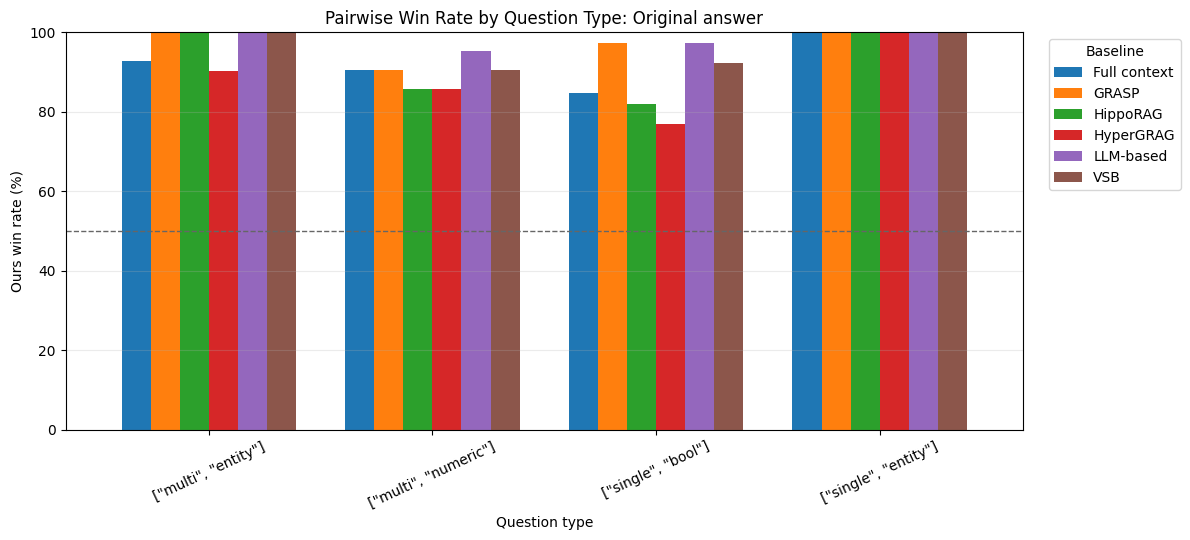

In [12]:
plot_qtype = ours_vs_baselines_by_qtype.copy()
plot_qtype["opponent_label"] = plot_qtype["opponent"].astype(str).map(lambda x: WINRATE_GRAPH_LABELS.get(x, x))
plot_qtype["ours_winrate_pct"] = plot_qtype["ours_winrate"] * 100

if plot_qtype.empty:
    print("No pairwise win-rate rows available for question-type plot.")
else:
    variant_order = [variant for variant, _dirname, _label in WINRATE_VARIANT_SPECS]
    for variant in variant_order:
        variant_df = plot_qtype[plot_qtype["winrate_variant"].eq(variant)]
        if variant_df.empty:
            continue
        ax = variant_df.pivot_table(
            index="ground_truth_qtype",
            columns="opponent_label",
            values="ours_winrate_pct",
            aggfunc="mean",
            observed=False,
        ).plot(
            kind="bar",
            figsize=(12, 5.5),
            rot=25,
            width=0.78,
        )
        ax.axhline(50, color="#666666", linestyle="--", linewidth=1)
        ax.set_ylim(0, 100)
        ax.set_ylabel("Ours win rate (%)")
        ax.set_xlabel("Question type")
        ax.set_title(f"Pairwise Win Rate by Question Type: {WINRATE_VARIANT_LABELS.get(variant, variant)}")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(title="Baseline", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
